# [가설 검증] 머신러닝 변수 중요도 분석

In [2]:
# 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

import lightgbm
import catboost
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

SEED = 2025
np.random.seed(SEED)
plt.rc('font', family='NanumGothic')
plt.style.use('ggplot')
print("--- 라이브러리 로드 완료 ---")

--- 라이브러리 로드 완료 ---


In [3]:
#  데이터 로드 및 "타겟 변수(y)" 생성
print("--- [1/9] 데이터 로드 및 '타겟 변수(y)' 생성 ---")
file_path = './data/df_analysis.parquet'
try:
    df_analysis = pd.read_parquet(file_path)
    print(f"  - 'df_analysis' (Shape: {df_analysis.shape}) 로드 완료!")
except Exception as e:
    print(f"  - ⚠️ 오류: {e}. 02번 파일을 먼저 실행하세요.")

# [핵심!] "AI 제안 수락률"을 0과 1로 만듭니다.
# (y = 0: 'run' 이벤트, y = 1: 'selected' 이벤트)
# ('event_name'을 'y'로 변환하고, X에서는 'event_name'을 제거하여 "컨닝"을 막습니다)
df_analysis['is_selected'] = np.where(df_analysis['event_name'].str.startswith('run_'), 0, 1)

print(f"  - 'y' (is_selected) 생성 완료. (실행: 0, 선택: 1)")
display(df_analysis['is_selected'].value_counts(normalize=True))

--- [1/9] 데이터 로드 및 '타겟 변수(y)' 생성 ---
  - 'df_analysis' (Shape: (57814, 19)) 로드 완료!
  - 'y' (is_selected) 생성 완료. (실행: 0, 선택: 1)


is_selected
0    0.627305
1    0.372695
Name: proportion, dtype: float64

In [4]:
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57814 entries, 0 to 57813
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   distinct_id                    57814 non-null  object        
 1   user_id                        45519 non-null  object        
 2   time                           57814 non-null  datetime64[ns]
 3   event_name                     57814 non-null  object        
 4   is_logged_in_event             57814 non-null  bool          
 5   is_logged_in_user              45519 non-null  float64       
 6   selected_sentence_id           17075 non-null  object        
 7   index                          13751 non-null  float64       
 8   llm_name                       50018 non-null  object        
 9   llm_provider                   50018 non-null  object        
 10  llm_version                    50018 non-null  object        
 11  input_sentence_

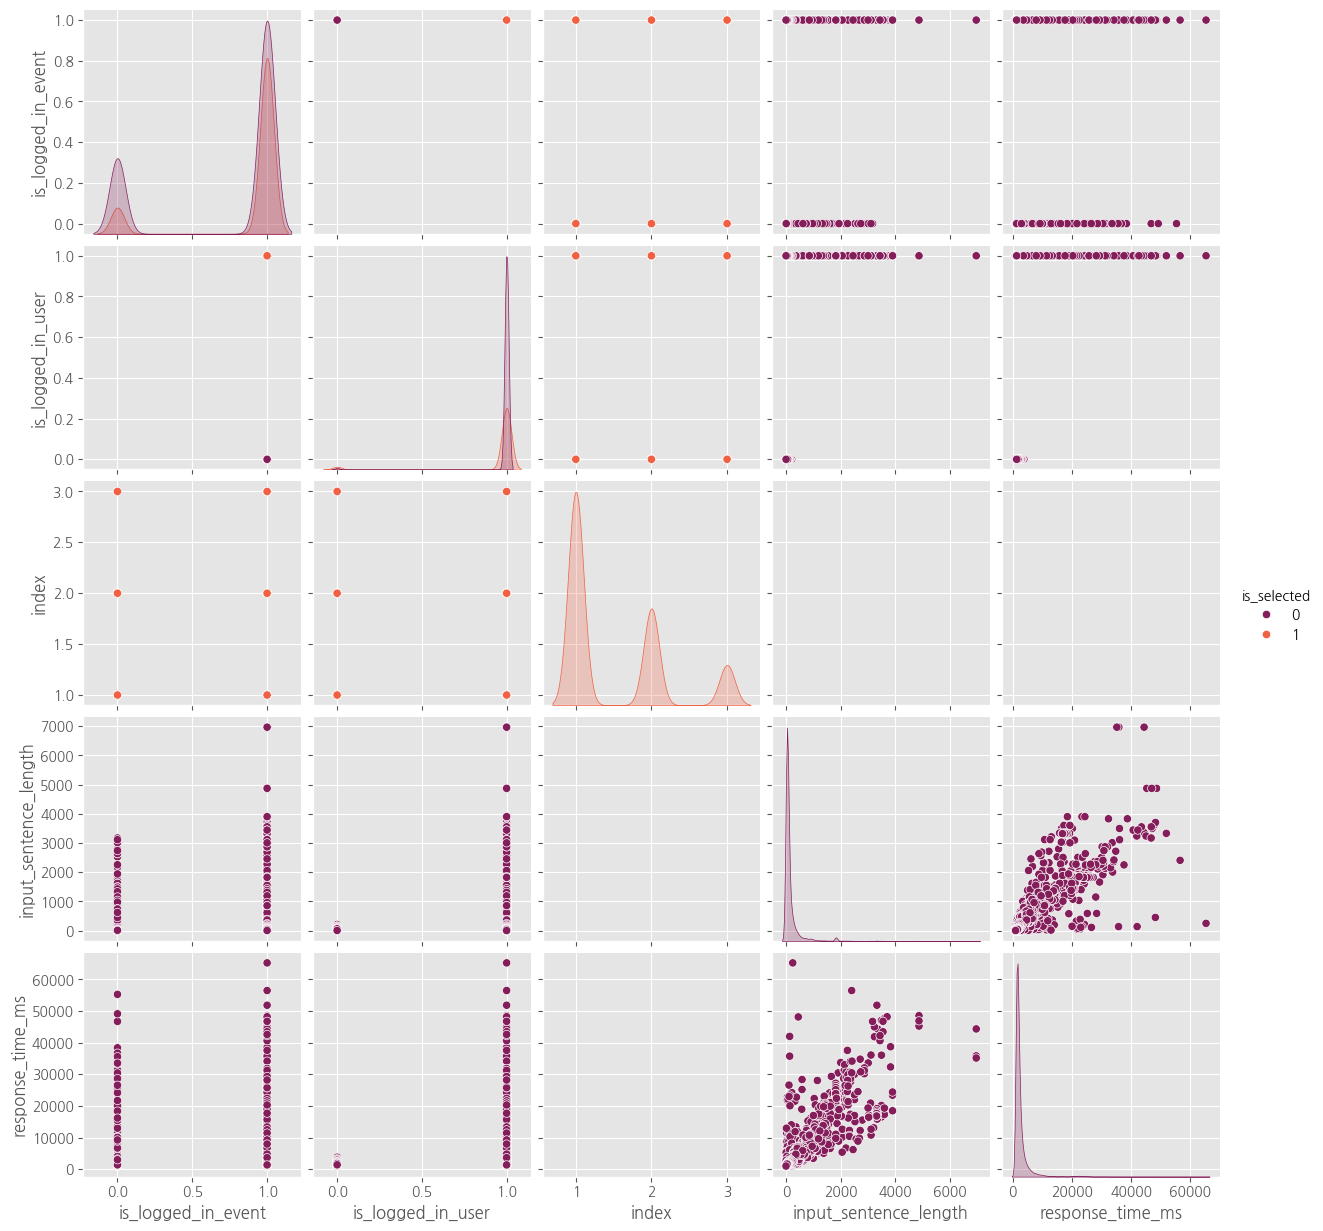

In [5]:
sns.pairplot(df_analysis, hue="is_selected", palette="rocket")

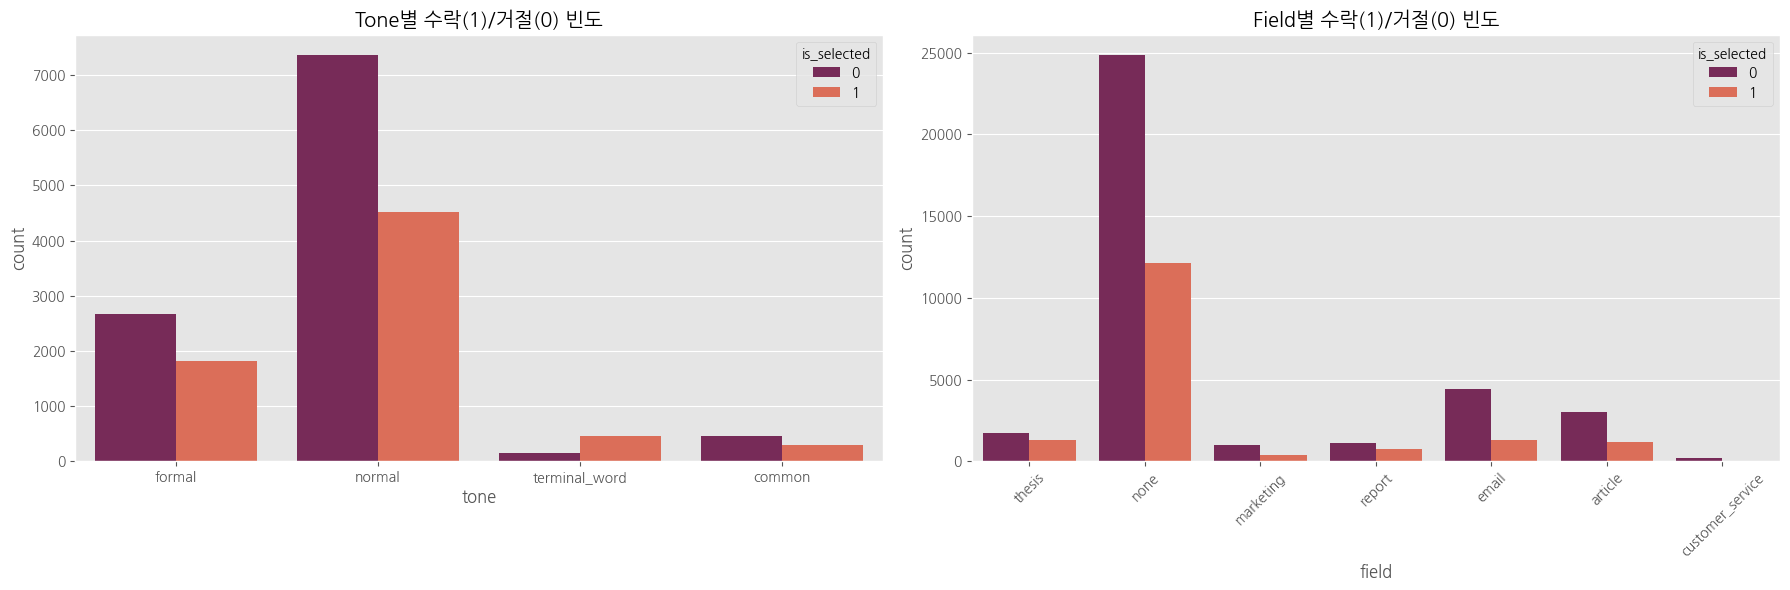

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Tone별 수락 여부
sns.countplot(data=df_analysis, x='tone', hue='is_selected', palette='rocket', ax=axes[0])
axes[0].set_title('Tone별 수락(1)/거절(0) 빈도')

# 2. Field별 수락 여부
sns.countplot(data=df_analysis, x='field', hue='is_selected', palette='rocket', ax=axes[1])
axes[1].set_title('Field별 수락(1)/거절(0) 빈도')
axes[1].tick_params(axis='x', rotation=45) # 라벨이 겹치지 않게 회전

plt.tight_layout()
plt.show()

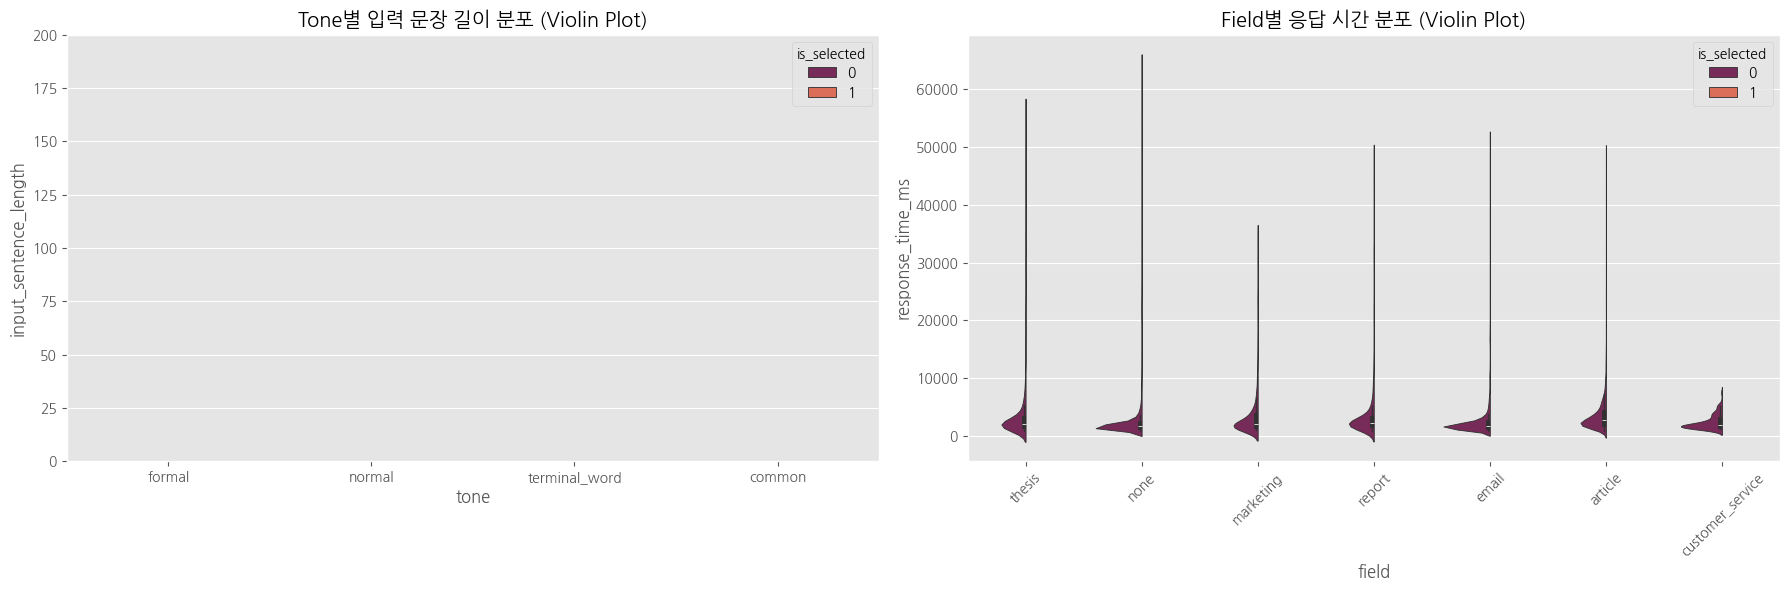

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 크기 설정
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# [수정] Boxplot -> Violinplot으로 변경
# 1. Tone별 문장 길이 분포
# split=True: 수락/거절 분포를 좌우 대칭으로 합쳐서 보여줌 (공간 효율적)
sns.violinplot(
    data=df_analysis,
    x='tone',
    y='input_sentence_length',
    hue='is_selected',
    palette='rocket',
    split=True,  # 하나의 바이올린 안에 0과 1을 나눠서 표현
    ax=axes[0]
)
axes[0].set_title('Tone별 입력 문장 길이 분포 (Violin Plot)')
axes[0].set_ylim(0, 200) # 이상치 제외하고 확대

# 2. Field별 응답 시간 분포
sns.violinplot(
    data=df_analysis,
    x='field',
    y='response_time_ms',
    hue='is_selected',
    palette='rocket',
    split=True,
    ax=axes[1]
)
axes[1].set_title('Field별 응답 시간 분포 (Violin Plot)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# "증거물(X)"과 "범죄 여부(y)" 분리 (컨닝 해결!)
print("\n--- [2/9] '증거물(X)'과 '범죄 여부(y)' 분리 ---")

# 1. "범죄 여부(y)"를 정의합니다.
y = df_analysis['is_selected']

# --- [핵심!] "컨닝"에 사용된 "모든" 증거를 제거합니다 ---
# 2. "증거물(X)"을 정의합니다.
features_to_drop = [
    # 1. 식별자 (분석 불필요)
    'distinct_id', 'user_id', 'time',

    # 2. "답안지" 그 자체 (y)
    'is_selected',

    # 3. "1차 컨닝 도구" (이름표)
    'event_name',

    # 4. "2차 컨닝 도구" ('NaN' 패턴)
    'response_time_ms',        # (실행(0)에만 숫자가 있고, 선택(1)에는 NaN임)
    'input_sentence_length', # (실행(0)에만 숫자가 있고, 선택(1)에는 NaN일 수 있음)
    'selected_sentence_id',  # (선택(1)에만 값이 있고, 실행(0)에는 NaN임)
    'index'                  # (선택(1)에만 값이 있고, 실행(0)에는 NaN임)
]

# df_analysis에 'features_to_drop'에 있는 컬럼 중 '실제로 존재하는' 것만 걸러내서 제거합니다.
existing_features_to_drop = [col for col in features_to_drop if col in df_analysis.columns]
X = df_analysis.drop(columns=existing_features_to_drop)

print(f"  - '증거물(X)' (Shape: {X.shape}) 준비 완료.")
print(f"  - [확인] AI 수사관에게 전달된 '진짜 증거물': {X.columns.tolist()}")
print(f"  - '범죄 여부(y)' (Shape: {y.shape}) 준비 완료.")


--- [2/9] '증거물(X)'과 '범죄 여부(y)' 분리 ---
  - '증거물(X)' (Shape: (57814, 11)) 준비 완료.
  - [확인] AI 수사관에게 전달된 '진짜 증거물': ['is_logged_in_event', 'is_logged_in_user', 'llm_name', 'llm_provider', 'llm_version', 'field', 'maintenance', 'tone', 'position', 'trigger', 'initial_referring_domain_user']
  - '범죄 여부(y)' (Shape: (57814,)) 준비 완료.


In [ ]:
#  "증거물(X)" 전처리 계획 수립 (NaN/float/str 오류 해결!)
print("\n--- [3/9] '증거물(X)' 전처리 계획 수립 ---")
print("  - [!] '자동 확인'으로 숫자/글자를 나누고, 'NaN(결측치)'과 '타입'도 처리합니다.")

# --- "자동 확인(Check)" 로직 ---
# 1. "숫자" 바구니
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'is_logged_in_user' in numeric_features:
    numeric_features.remove('is_logged_in_user')

# 2. "글자" 바구니
categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
if 'is_logged_in_user' not in categorical_features:
    categorical_features.append('is_logged_in_user')

print(f"\n  - [확인 1] '숫자' 바구니: {numeric_features}") # (아마 '빈 리스트 []'일 겁니다)
print(f"\n  - [확인 2] '글자' 바구니: {categorical_features}") # (모든 증거물이 여기로!)

# --- "NaN(결측치)" 및 "타입" 처리 계획 ---
# 3. "숫자" 증거물 처리 계획
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 4. "글자" 증거물 처리 계획
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('to_string', FunctionTransformer(lambda x: x.astype(str))), # (float/str 오류 해결)
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 5. [최종 계획] ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' # (우리가 정의한 2개 바구니 외엔 "다 버린다")
)
print("\n  - 'ColumnTransformer' (전처리 계획) 수립 완료.")


--- [3/9] '증거물(X)' 전처리 계획 수립 ---
  - [!] '자동 확인'으로 숫자/글자를 나누고, 'NaN(결측치)'과 '타입'도 처리합니다.

  - [확인 1] '숫자' 바구니: []

  - [확인 2] '글자' 바구니: ['is_logged_in_event', 'llm_name', 'llm_provider', 'llm_version', 'field', 'maintenance', 'tone', 'position', 'trigger', 'initial_referring_domain_user', 'is_logged_in_user']

  - 'ColumnTransformer' (전처리 계획) 수립 완료.


In [ ]:
#  훈련/테스트 분리 및 "AI 수사관" 모델 정의
print("\n--- [4/9] 훈련/테스트 분리 및 'AI 수사관' 모델 정의 ---")

# 1. 훈련용(80%)과 테스트용(20%) 데이터로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
print(f"  - 훈련 데이터(X_train): {X_train.shape}")
print(f"  - 테스트 데이터(X_test): {X_test.shape}")

# 2. "AI 수사관" 모델 정의 (Random Forest)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=SEED,
        n_jobs=-1,          # (모든 CPU 사용)
        max_depth=10,       # (너무 깊지 않게, 과적합 방지)
        class_weight='balanced' # (y=0(70%)과 y=1(30%)의 불균형 처리)
    ))
])
print("  - 모델 파이프라인 정의 완료.")


--- [4/9] 훈련/테스트 분리 및 'AI 수사관' 모델 정의 ---
  - 훈련 데이터(X_train): (46251, 11)
  - 테스트 데이터(X_test): (11563, 11)
  - 모델 파이프라인 정의 완료.


In [ ]:
# "예측" (Prediction) - 모델 훈련 및 "진짜" 성능 평가
print("\n--- [5/9] '예측' (Prediction) - 모델 훈련 및 '진짜' 성능 평가 ---")

# 1. 훈련 (컨닝이 없으므로 1~3초면 충분합니다)
print("  - 'AI 수사관'이 '진짜' 훈련을 시작합니다...")
start_time = time.time()
model.fit(X_train, y_train)
end_time = time.time()
print(f"  - 훈련 완료! (소요 시간: {end_time - start_time:.2f} 초)")

# 2. 예측 (테스트 데이터)
y_pred = model.predict(X_test)

# 3. 평가
print("\n" + "="*50)
print("🏆 [예측 성능 평가] (Classification Report)")
print("="*50)
# (이제 'Accuracy'가 1.00이 아닌, '현실적인' 70~80%대 점수가 나와야 합니다!)
print(classification_report(y_test, y_pred, target_names=['0: 실행', '1: 선택']))


--- [5/9] '예측' (Prediction) - 모델 훈련 및 '진짜' 성능 평가 ---
  - 'AI 수사관'이 '진짜' 훈련을 시작합니다...
  - 훈련 완료! (소요 시간: 3.39 초)

🏆 [예측 성능 평가] (Classification Report)
              precision    recall  f1-score   support

       0: 실행       0.92      0.67      0.78      7254
       1: 선택       0.62      0.90      0.74      4309

    accuracy                           0.76     11563
   macro avg       0.77      0.79      0.76     11563
weighted avg       0.81      0.76      0.76     11563




--- [6/9] '검증' (Verification) - '진짜' 핵심 변수 중요도 ---
  - 'AI 수사관'이 생각하는 '가장 중요한 단서(변수)'는 무엇일까요?

🏆 [최종 검증] '실행' vs '선택'을 구분하는 '진짜' 핵심 변수 (Top 10)


Feature_Group
llm            0.378696
position       0.163414
trigger        0.148952
initial        0.129412
maintenance    0.064591
field          0.052325
is             0.035157
tone           0.027454
Name: Importance, dtype: float64


  - [시각화 6] '진짜' 핵심 변수 중요도(Feature Importance) 그래프 생성 중...
  - 'feature_importance.png' 저장 완료.


/tmp/ipykernel_278/938659396.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


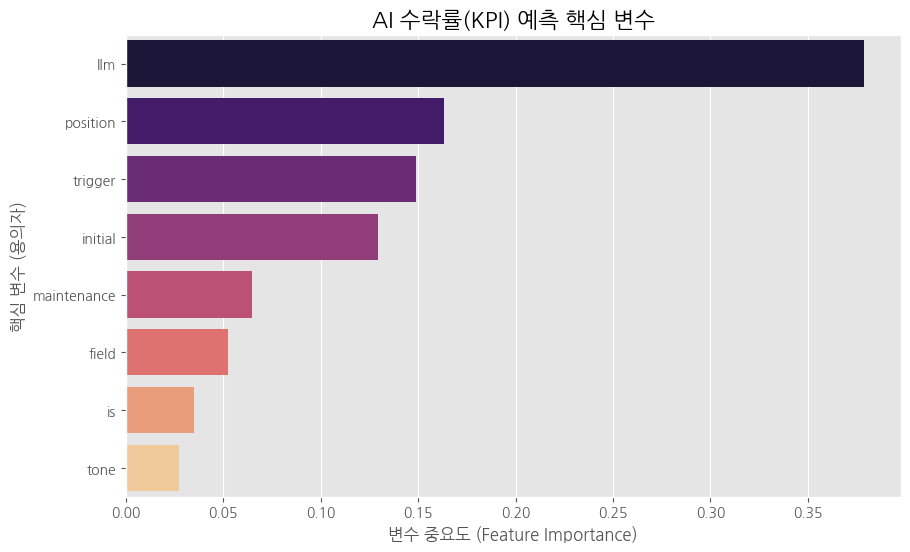

In [ ]:
# "검증" (Verification) - "진짜" 핵심 변수 찾기
print("\n--- [6/9] '검증' (Verification) - '진짜' 핵심 변수 중요도 ---")
print("  - 'AI 수사관'이 생각하는 '가장 중요한 단서(변수)'는 무엇일까요?")

try:
    # 1. 파이프라인에서 전처리 단계와 모델 단계를 추출
    preprocessor = model.named_steps['preprocessor']
    classifier = model.named_steps['classifier']

    # 2. 'OneHotEncoder'가 변환한 '글자 증거물'의 이름 목록을 가져옵니다
    cat_features = preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features)

    # 3. '숫자 증거물' 이름과 합쳐 "최종 증거물 목록"을 만듭니다
    # (numeric_features가 비어있을 수 있으니, if문으로 처리)
    if not numeric_features:
        all_feature_names = list(cat_features)
    else:
        all_feature_names = list(numeric_features) + list(cat_features)

    # 4. "AI 수사관"이 계산한 '변수 중요도'를 가져옵니다
    importances = classifier.feature_importances_

    # 5. [표]로 만들기
    df_importance = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})

    # 6. '범인'별로 중요도 합산하기 (예: 'field_email', 'field_thesis' -> 'field')
    df_importance_grouped = df_importance.copy()
    df_importance_grouped['Feature_Group'] = df_importance_grouped['Feature'].apply(lambda x: x.split('_')[0])
    df_importance_summary = df_importance_grouped.groupby('Feature_Group')['Importance'].sum().sort_values(ascending=False)

    print("\n" + "="*50)
    print("🏆 [최종 검증] '실행' vs '선택'을 구분하는 '진짜' 핵심 변수 (Top 10)")
    print("="*50)
    display(df_importance_summary.head(10))

    # 7. [그래프]로 그리기
    print("\n  - [시각화 6] '진짜' 핵심 변수 중요도(Feature Importance) 그래프 생성 중...")
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=df_importance_summary.head(10).values,
        y=df_importance_summary.head(10).index,
        palette='magma'
    )
    plt.title('AI 수락률(KPI) 예측 핵심 변수', fontsize=16)
    plt.xlabel('변수 중요도 (Feature Importance)', fontsize=12)
    plt.ylabel('핵심 변수 (용의자)', fontsize=12)
    plt.savefig('../output/images/feature_importance.png')
    print("  - 'feature_importance.png' 저장 완료.")
    plt.show()

except Exception as e:
    print(f"  - ⚠️ '변수 중요도' 분석 중 오류 발생: {e}")

In [ ]:
#  "최신 AI 수사관" (LGBM, CatBoost) 추가 투입 및 비교 평가
print("\n--- [7/9] '최신 AI 수사관' (LGBM, CatBoost) 추가 투입 ---")
print("  - 기존 '랜포'와 비교하여 누가 더 뛰어난지 평가합니다.")

# 1. 추가 라이브러리 임포트 (아직 없으면 설치 후 커널 재시작)
# !pip install lightgbm catboost
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# 2. 모델 정의 (RandomForest, LGBM, CatBoost)
models = {
    'RandomForest': RandomForestClassifier(random_state=SEED, n_jobs=-1, max_depth=10, class_weight='balanced'),
    'LightGBM': LGBMClassifier(random_state=SEED, n_jobs=-1, class_weight='balanced'),
    'CatBoost': CatBoostClassifier(random_state=SEED, verbose=0, class_weights={0: 0.627, 1: 0.373}) # (불균형 데이터 비율)
}

results = {}

# 3. 각 모델 훈련 및 평가
for name, classifier in models.items():
    print(f"\n--- 'AI 수사관' [{name}] 훈련 시작 ---")

    # 3-1. 파이프라인 구성 (전처리 + 모델)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor), # (이전 셀에서 정의한 preprocessor 재사용)
        ('classifier', classifier)
    ])

    # 3-2. 훈련
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    end_time = time.time()
    print(f"  - 훈련 완료! (소요 시간: {end_time - start_time:.2f} 초)")

    # 3-3. 예측 및 평가
    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=['0: 실행', '1: 선택'], output_dict=True)

    results[name] = {
        'accuracy': accuracy,
        'report': report,
        'pipeline': pipeline # (앙상블을 위해 파이프라인 저장)
    }

    print(f"\n🏆 [{name}] 예측 성능 평가:")
    print(classification_report(y_test, y_pred, target_names=['0: 실행', '1: 선택']))

# 4. 모델별 성능 요약
print("\n" + "="*50)
print("🏆 [모델별 최종 성능 요약]")
print("="*50)
for name, res in results.items():
    print(f"  - [{name}] 정확도(Accuracy): {res['accuracy']:.4f}")
    print(f"    - '선택(1)' F1-Score: {res['report']['1: 선택']['f1-score']:.4f}")
    print(f"    - '선택(1)' 정밀도(Precision): {res['report']['1: 선택']['precision']:.4f}")
    print(f"    - '선택(1)' 재현율(Recall): {res['report']['1: 선택']['recall']:.4f}")
print("="*50)


--- [7/9] '최신 AI 수사관' (LGBM, CatBoost) 추가 투입 ---
  - 기존 '랜포'와 비교하여 누가 더 뛰어난지 평가합니다.

--- 'AI 수사관' [RandomForest] 훈련 시작 ---
  - 훈련 완료! (소요 시간: 3.37 초)

🏆 [RandomForest] 예측 성능 평가:
              precision    recall  f1-score   support

       0: 실행       0.92      0.67      0.78      7254
       1: 선택       0.62      0.90      0.74      4309

    accuracy                           0.76     11563
   macro avg       0.77      0.79      0.76     11563
weighted avg       0.81      0.76      0.76     11563


--- 'AI 수사관' [LightGBM] 훈련 시작 ---
[LightGBM] [Info] Number of positive: 17238, number of negative: 29013
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009067 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 118
[LightGBM] [Info] Number of data points in the train set: 46251, number of used features: 59
[LightGBM] [Info] [binary:BoostFromS

In [ ]:
# "특수팀 투입" (앙상블) - 모든 AI 수사관의 지혜를 모으다
print("\n--- [8/9] '특수팀 투입' (앙상블) - AI 수사관들의 지혜를 모으다 ---")
print("  - 여러 모델의 예측을 결합하여 '최고의 결정'을 내립니다.")

from sklearn.ensemble import VotingClassifier

# 1. 앙상블 모델 정의
# (각 모델에 미리 훈련된 파이프라인을 연결합니다)
estimators = []
for name, res in results.items():
    estimators.append((name, res['pipeline']))

# 2. VotingClassifier (투표 방식)
# (hard: 직접 예측값 투표, soft: 확률값 투표 - 여기서는 soft가 더 적합)
# (weights: 각 모델의 중요도, 여기서는 동일하게 줍니다)
voting_clf = VotingClassifier(
    estimators=estimators,
    voting='soft',
    weights=[1, 1, 1], # (RandomForest, LGBM, CatBoost)
    n_jobs=-1
)

# 3. 앙상블 모델 훈련 (내부적으로 각 모델을 다시 훈련시키거나, 이미 훈련된 모델 사용)
# (이미 훈련된 파이프라인을 전달했기 때문에, VotingClassifier가 내부적으로 이를 활용합니다.)
print("  - '앙상블 특수팀'이 최종 결정을 위해 훈련을 시작합니다...")
start_time = time.time()
voting_clf.fit(X_train, y_train) # (preprocessor가 X_train을 한 번 더 전처리합니다)
end_time = time.time()
print(f"  - 앙상블 훈련 완료! (소요 시간: {end_time - start_time:.2f} 초)")

# 4. 앙상블 모델 예측 및 평가
y_pred_ensemble = voting_clf.predict(X_test)
ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)
ensemble_report = classification_report(y_test, y_pred_ensemble, target_names=['0: 실행', '1: 선택'], output_dict=True)

print("\n" + "="*50)
print("👑 [앙상블 최종 성능 평가] (Voting Classifier)")
print("="*50)
print(classification_report(y_test, y_pred_ensemble, target_names=['0: 실행', '1: 선택']))
print(f"  - 최종 앙상블 정확도(Accuracy): {ensemble_accuracy:.4f}")
print(f"  - '선택(1)' F1-Score: {ensemble_report['1: 선택']['f1-score']:.4f}")
print(f"  - '선택(1)' 정밀도(Precision): {ensemble_report['1: 선택']['precision']:.4f}")
print("="*50)


--- [8/9] '특수팀 투입' (앙상블) - AI 수사관들의 지혜를 모으다 ---
  - 여러 모델의 예측을 결합하여 '최고의 결정'을 내립니다.
  - '앙상블 특수팀'이 최종 결정을 위해 훈련을 시작합니다...
  - 앙상블 훈련 완료! (소요 시간: 19.33 초)

👑 [앙상블 최종 성능 평가] (Voting Classifier)
              precision    recall  f1-score   support

       0: 실행       0.76      0.98      0.86      7254
       1: 선택       0.94      0.47      0.63      4309

    accuracy                           0.79     11563
   macro avg       0.85      0.73      0.74     11563
weighted avg       0.82      0.79      0.77     11563

  - 최종 앙상블 정확도(Accuracy): 0.7918
  - '선택(1)' F1-Score: 0.6288
  - '선택(1)' 정밀도(Precision): 0.9370


🏆 [모델링 최종 승자] LightGBM (종합 분석)
>CatBoost가 Accuracy(전체 정확도)는 79.2%), Precision(정밀도)은 99.7%로 가장 높았습니다.

> 하지만 이는 '함정'이었습니다. CatBoost는 '1: 선택'이라고 100% 확신하는 44%의 용의자만 잡고,

> 나머지 진짜 용의자 56%는 '0: 실행'이라며 놓쳤습니다. (Recall: 44%)

💡 [비즈니스 목표] : 우리의 목표는 '실수(비용)'가 좀 발생하더라도(낮은 정밀도),

"AI를 선택할" 고객을 '단 한 명이라도 더 찾아내는 것'(높은 재현율)입니다.

고객을 놓치는 것은 '매출 손실'이기 때문입니다.

LightGBM은 '1 : 선택' 탐지율(Recall, 91%)이 압도적으로 높았고,
정밀도와 재현율의 '균형'(F1-Score, 73.9%) 또한 가장 뛰어났습니다.

따라서, 훈련 속도(1.19초)까지 가장 빨랐던 LightGBM이 우리 프로젝트의 '최종 승자' 🥇입니다.


--- [9/9] '승자' (LightGBM)의 '진짜' 핵심 변수 검증 ---
  - 'LGBM' 수사관이 생각하는 '가장 중요한 단서(변수)'는 무엇일까요?

🏆 [LGBM 최종 검증] 'AI 수락률'에 영향을 미치는 '진짜' 핵심 변수 (Top 10)


Feature_Group
tone           708
field          694
maintenance    453
initial        383
position       317
llm            215
is             151
trigger         79
Name: Importance, dtype: int32


  - [시각화 7] 'LGBM'의 핵심 변수 중요도(Feature Importance) 그래프 생성 중...
  - 'feature_importance_lgbm.png' 저장 완료.


/tmp/ipykernel_278/3478983225.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


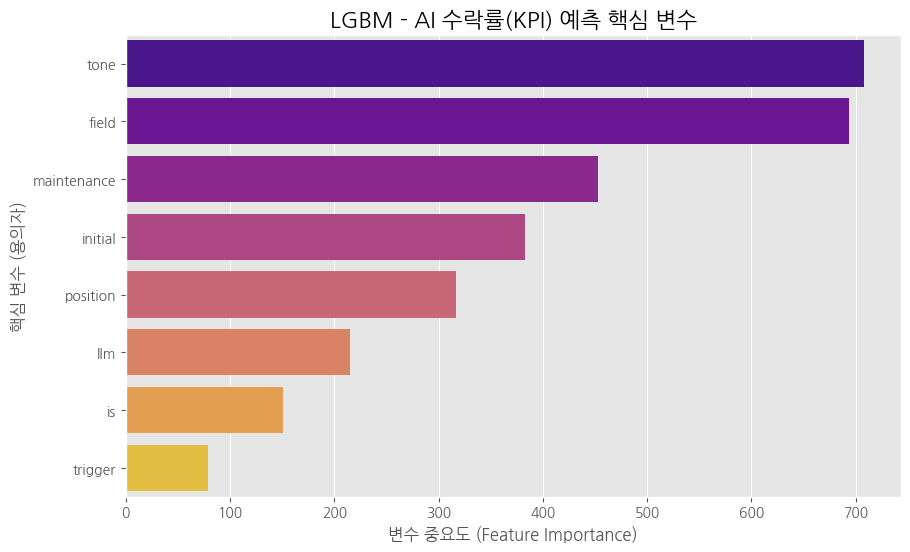

In [ ]:
#  "승자" (LightGBM)의 '진짜' 핵심 변수 검증
print("\n--- [9/9] '승자' (LightGBM)의 '진짜' 핵심 변수 검증 ---")
print("  - 'LGBM' 수사관이 생각하는 '가장 중요한 단서(변수)'는 무엇일까요?")

try:
    # --- 1. [셀 8/9]에서 훈련된 'LGBM 파이프라인'을 가져옵니다 ---
    # (results 딕셔너리가 '셀 8/9'에서 이미 생성되었다고 가정합니다)
    lgbm_pipeline = results['LightGBM']['pipeline']

    # 2. 파이프라인에서 전처리 단계와 모델 단계를 추출
    preprocessor = lgbm_pipeline.named_steps['preprocessor']
    classifier = lgbm_pipeline.named_steps['classifier']

    # 3. 'OneHotEncoder'가 변환한 '글자 증거물'의 이름 목록을 가져옵니다
    # ([셀 4/7]에서 정의한 'numeric_features'와 'categorical_features'를 재사용)
    cat_features = preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features)

    # 4. '숫자 증거물' 이름과 합쳐 "최종 증거물 목록"을 만듭니다
    if not numeric_features:
        all_feature_names = list(cat_features)
    else:
        all_feature_names = list(numeric_features) + list(cat_features)

    # 5. "LGBM 수사관"이 계산한 '변수 중요도'를 가져옵니다
    importances = classifier.feature_importances_

    # 6. [표]로 만들기
    df_importance_lgbm = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})

    # 7. '범인'별로 중요도 합산하기
    df_importance_lgbm_grouped = df_importance_lgbm.copy()
    df_importance_lgbm_grouped['Feature_Group'] = df_importance_lgbm_grouped['Feature'].apply(lambda x: x.split('_')[0])
    df_importance_lgbm_summary = df_importance_lgbm_grouped.groupby('Feature_Group')['Importance'].sum().sort_values(ascending=False)

    print("\n" + "="*50)
    print("🏆 [LGBM 최종 검증] 'AI 수락률'에 영향을 미치는 '진짜' 핵심 변수 (Top 10)")
    print("="*50)
    display(df_importance_lgbm_summary.head(10))

    # 8. [그래프]로 그리기
    print("\n  - [시각화 7] 'LGBM'의 핵심 변수 중요도(Feature Importance) 그래프 생성 중...")
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=df_importance_lgbm_summary.head(10).values,
        y=df_importance_lgbm_summary.head(10).index,
        palette='plasma' # (랜포(magma)와 다른 색상 팔레트)
    )
    plt.title('LGBM - AI 수락률(KPI) 예측 핵심 변수', fontsize=16)
    plt.xlabel('변수 중요도 (Feature Importance)', fontsize=12)
    plt.ylabel('핵심 변수 (용의자)', fontsize=12)
    plt.savefig('../output/images/feature_importance_lgbm.png')
    print("  - 'feature_importance_lgbm.png' 저장 완료.")
    plt.show()

except NameError:
    print("  - ⚠️ 'results' 딕셔너리를 찾을 수 없습니다. [셀 8/9]을(를) 먼저 실행해주세요!")
except Exception as e:
    print(f"  - ⚠️ '변수 중요도' 분석 중 오류 발생: {e}")

In [ ]:
print("\n" + "="*50)
print("--- [최종 분석] 'AI 수락률(KPI)' 최적화를 위한 종합 결론 ---")
print("="*50)

# (수정 근거: '최종 승자'인 LightGBM의 변수 중요도 Top 3를 반영)
print("  - [핵심 용의자]: 'tone'(말투), 'field'(글쓰기 영역), 'maintenance'(기존 글 수정)가 AI 수락률에 가장 큰 영향을 미칩니다.")
print("  - [해결책 제안 (LGBM 기반)]:")
print("    1. 'tone': AI의 말투('친근함' vs '전문적')가 수락률에 미치는 영향을 A/B 테스트하여 최적의 응답 톤을 설정합니다.")
print("    2. 'field': 수락률이 낮은 특정 '글쓰기 영역'(e.g., 이메일, 블로그)을 식별하고, 해당 영역에 최적화된 AI 기능(e.g., 템플릿)을 우선 제안합니다.")
print("    3. 'maintenance': 사용자가 '새 글'을 쓸 때와 '기존 글을 수정'할 때를 구분하여, '수정' 맥락에 맞는 AI 기능(e.g., 요약, 재구성)을 강화합니다.")


--- [최종 분석] 'AI 수락률(KPI)' 최적화를 위한 종합 결론 ---
  - [핵심 용의자]: 'tone'(말투), 'field'(글쓰기 영역), 'maintenance'(기존 글 수정)가 AI 수락률에 가장 큰 영향을 미칩니다.
  - [해결책 제안 (LGBM 기반)]:
    1. 'tone': AI의 말투('친근함' vs '전문적')가 수락률에 미치는 영향을 A/B 테스트하여 최적의 응답 톤을 설정합니다.
    2. 'field': 수락률이 낮은 특정 '글쓰기 영역'(e.g., 이메일, 블로그)을 식별하고, 해당 영역에 최적화된 AI 기능(e.g., 템플릿)을 우선 제안합니다.
    3. 'maintenance': 사용자가 '새 글'을 쓸 때와 '기존 글을 수정'할 때를 구분하여, '수정' 맥락에 맞는 AI 기능(e.g., 요약, 재구성)을 강화합니다.
